# Phase 1 — Supervised Learning
## IBM HR Employee Attrition Dataset
---

## **Model Selection Rationale**

### 1. Logistic Regression
#### i. Dataset Characteristics

Logistic Regression performs reliably on small-to-medium sized datasets. In our chosen dataset we have only 1,470 records which is a small number in comparision to large corporate HR databases, which makes complex models risk overfitting. Logistic Regression's simplicity is an advantage here where it generalizes well without requiring thousands of records to learn from.

Additionaly, our dataset contains 26 numerical features (e.g., `Age`, `MonthlyIncome`, `YearsAtCompany`) and 8 categorical features (e.g., `JobRole`, `Department`). After encoding categorical variables and scaling numerical ones, Logistic Regression handles this mix effectively.

And lastly, Logistic Regression assumes a linear relationship between input features and the log-odds of attrition. While actual attrition may involve some non-linear interactions, however there are many key features that expects to have a strong linear relationship with attrition probability such as `MonthlyIncome`, `OverTime`, and `JobSatisfaction`. 

#### ii. Problem Type — Binary Classification

The target variable `Attrition` has exactly two classes: **Yes** (employee left) and **No** (employee stayed). Logistic Regression was specifically designed for binary classification problems where it gives a probability result between 0 and 1, which maps naturally to our Yes/No prediction.

#### iii. Model Strengths & Weaknesses for This Problem

**Strengths:**
- **Interpretability:** Each feature receives a coefficient that directly indicates its direction and magnitude of influence on attrition. For example, a high positive coefficient for `OverTime_Yes` tells us that working overtime strongly increases the probability of leaving. This is extremely valuable for HR decision-makers.
- **Baseline benchmark:** Logistic Regression serves as the standard baseline that all other models should outperform. If a complex model cannot beat Logistic Regression, it is likely overfitting.
- **No hyperparameter complexity:** Requires minimal tuning, making results reproducible and stable.
- **Fast training:** Computationally inexpensive, important when iterating quickly.
- **Probabilistic output:** Provides confidence scores per prediction, not just binary labels.

**Weaknesses:**
- **Linearity assumption:** Cannot automatically capture non-linear interactions between features (e.g., the combined effect of low salary AND high overtime).
- **Feature engineering dependency:** Requires manual encoding and scaling to handle categorical features.
- **Class imbalance sensitivity:** With 1,233 'No' vs. 237 'Yes' (~84%/16% split), the model may be biased toward predicting 'No'. We address this with `class_weight='balanced'`.

### 2. SVM
#### i. Dataset Characteristics

#### ii. Problem Type — Binary Classification

#### iii. Model Strengths & Weaknesses for This Problem

### 3. XGBoost/Random Forest
#### i. Dataset Characteristics

#### ii. Problem Type — Binary Classification

#### iii. Model Strengths & Weaknesses for This Problem
---

## **Implementation & Training**


### 1. Logistic Regression

In [58]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────

#for loading and manipulating our dataset
import pandas as pd

#for numerical operations
import numpy as np

#for creating plots and visualizations
import matplotlib.pyplot as plt
import seaborn as sns

#to turn off minor warnings so the output stays clean and readable
import warnings
warnings.filterwarnings('ignore')


#train_test_split for spliting our data into training and testing sets
#StratifiedKFold for keeping class ratios balanced in each fold
from sklearn.model_selection import train_test_split, StratifiedKFold

#StandardScaler for scaleomg all numerical features to have mean=0 and std=1
from sklearn.preprocessing import StandardScaler

#the actual model we are implementing
from sklearn.linear_model import LogisticRegression

#evaluation tools
from sklearn.metrics import (
    accuracy_score,       # percentage of correct predictions
    precision_score,      # of all predicted 'Left', how many actually left?
    recall_score,         # of all who actually left, how many did we catch?
    f1_score,             # harmonic mean of precision and recall
    confusion_matrix,     # table showing TP, TN, FP, FN
    classification_report,# full summary of all metrics per class
    roc_auc_score,        # area under the ROC curve (overall model quality)
    roc_curve,            # the actual curve data points for plotting
    ConfusionMatrixDisplay# a helper to plot the confusion matrix nicely
)

# for automating hyperparameter tuning
from sklearn.model_selection import GridSearchCV, cross_validate

print("All libraries imported successfully.")

import os

# Create all output folders automatically
# exist_ok=True means: if folder already exists, do nothing (no error)
# This runs safely every time — creates if missing, skips if already there
os.makedirs('Supervised_Learning/models', exist_ok=True)
os.makedirs('Supervised_Learning/evaluation_results', exist_ok=True)
os.makedirs('Supervised_Learning/plots', exist_ok=True) 

print("Output folders ready.")

All libraries imported successfully.
Output folders ready.


In [59]:
# ── Load the preprocessed dataset ────────────────────────────────────────────
# pd.read_csv() reads the CSV file into a DataFrame (a table structure)
df = pd.read_csv('phase1_preprocessed_final.csv')

# Quick sanity checks
print(f"Shape: {df.shape}")  # expect (1470, 54)
print(f"Missing values: {df.isnull().sum().sum()}")  # expect 0
print(f"\nAttrition distribution:")
print(df['Attrition'].value_counts())
print(f"\nAttrition rate: {df['Attrition'].mean()*100:.1f}% left the company")

df.head(3)

Shape: (1470, 54)
Missing values: 0

Attrition distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

Attrition rate: 16.1% left the company


,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,PromotionRatio,IncomePerYear,RoleStabilityRatio,AgeGroup,SatisfactionScore,LowSatisfactionFlag
0,0.446350,1,1,0.742527,-1.010909,2,2,Female,1.383138,3,...,False,False,False,True,0.000000,665.888889,0.571429,1,2.333333,0
1,1.322365,0,2,-1.297775,-0.147150,1,3,Male,-0.240677,2,...,False,False,True,False,0.090909,466.363636,0.636364,2,3.000000,0
2,0.008343,1,1,1.414363,-0.887515,2,4,Male,1.284725,2,...,False,False,False,True,0.000000,261.250000,0.000000,1,3.000000,0


Before training our **Logistic Regression model**, we need to ensure that all features are numeric.

Two columns are stored as text and must be encoded:
- **Gender**: Female → 0, Male → 1  
- **OverTime**: No → 0, Yes → 1  

Additionally, the one-hot encoded columns are currently stored as **boolean values (True/False)**.  
Since machine learning models in **scikit-learn require numeric inputs**, these columns are converted to **integers (1/0)**.

Finally, to keep feature scales consistent across the dataset the three engineered features — **PromotionRatio**, **IncomePerYear**, and **RoleStabilityRatio** are going to be standardized using **StandardScaler**.

In [60]:
# ── Encode Gender (binary categorical) ──────────────────────────────────
# Female → 0, Male → 1
# the map() replaces each value based on the dictionary I provided
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
print("Gender encoded:", df['Gender'].unique())  # should show [0, 1]

# ── Encode OverTime (binary categorical) ────────────────────────────────
# No → 0, Yes → 1
df['OverTime'] = df['OverTime'].map({'No': 0, 'Yes': 1})
print("OverTime encoded:", df['OverTime'].unique())  # should show [0, 1]

# ── Convert bool columns to int ────────────────────────────────────────
# The One-Hot Encoded columns during the data preprocessing (Department_Sales, JobRole_Manager, etc.) are True/False
# sklearn needs them as 1/0 integers
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)
print(f"\nConverted {len(bool_cols)} bool columns to int.")
print(f"Bool columns: {bool_cols}")

# ── Scale the 3 engineered ratio features ───────────────────────────────
# These were created after the main scaling step during the data processing, so they are on different scales:
#   PromotionRatio:    0.0 → 0.92
#   IncomePerYear:     95  → 1904
#   RoleStabilityRatio: 0.0 → 1.0
# We scale them now to match all other features
cols_to_scale = ['PromotionRatio', 'IncomePerYear', 'RoleStabilityRatio']
extra_scaler = StandardScaler()
df[cols_to_scale] = extra_scaler.fit_transform(df[cols_to_scale])
print(f"\nScaled engineered features: {cols_to_scale}")
print(f"IncomePerYear mean after scaling: {df['IncomePerYear'].mean():.4f} (should be ~0)")

# Final check — all columns should now be numeric
remaining_strings = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"\nRemaining non-numeric columns: {remaining_strings}")  # should be empty []

Gender encoded: [0 1]
OverTime encoded: [1 0]

Converted 21 bool columns to int.
Bool columns: ['Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole_Sales Representative', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single']

Scaled engineered features: ['PromotionRatio', 'IncomePerYear', 'RoleStabilityRatio']
IncomePerYear mean after scaling: -0.0000 (should be ~0)

Remaining non-numeric columns: []


For Logistic Regression model the dataset needs to be divided into **X (features)** and **y (target)**, where `Attrition` is the variable the model will predict.

In [61]:
# ── Separate features and target ──────────────────────────────────────────────

# X = everything EXCEPT the Attrition column
# .drop(columns=['Attrition']) creates a copy of df without that column
X = df.drop(columns=['Attrition'])

# y = ONLY the Attrition column (0 = stayed, 1 = left)
y = df['Attrition']

print(f"X shape: {X.shape}")
print(f"→ {X.shape[0]} employees, {X.shape[1]} features each")
print(f"\ny shape: {y.shape}")
print(f"→ {y.shape[0]} labels (one 0 or 1 per employee)")
print(f"\nAll features ({X.shape[1]} total):")
print(list(X.columns))

X shape: (1470, 53)
→ 1470 employees, 53 features each

y shape: (1470,)
→ 1470 labels (one 0 or 1 per employee)

All features (53 total):
['Age', 'BusinessTravel', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'JobRole_Healthcare Representative', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manag

The dataset is split into **training (80%)** and **test (20%)** sets.  
`stratify=y` ensures both sets keep the original class distribution (**83.9% stayed, 16.1% left**) so evaluation remains reliable.

In [62]:
# ── Train/Test Split ──────────────────────────────────────────────────────────

X_train, X_test, y_train, y_test = train_test_split(
    X,               # feature matrix
    y,               # target vector
    test_size=0.2,   # 20% → test set, 80% → training set
    random_state=42, # fixed seed: guarantees the same split every time this runs
    stratify=y       # ensures both sets keep the original 83.9%/16.1% class ratio preventing the test set from accidentally having too few 'Left' cases
)

# Confirm sizes
print(f"Training set: {X_train.shape[0]} records ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:     {X_test.shape[0]} records ({X_test.shape[0]/len(X)*100:.0f}%)")

# Verify stratification worked — both should show ~16% attrition rate
print(f"\nAttrition rate — Training: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")
print(f"(Both should be close to 16.1% — if so, stratification worked correctly)")

print(f"\nTraining class counts: {y_train.value_counts().to_dict()}")
print(f"Test class counts:     {y_test.value_counts().to_dict()}")

Training set: 1176 records (80%)
Test set:     294 records (20%)

Attrition rate — Training: 16.2% | Test: 16.0%
(Both should be close to 16.1% — if so, stratification worked correctly)

Training class counts: {0: 986, 1: 190}
Test class counts:     {0: 247, 1: 47}


The Logistic Regression model is created now and trained using the prepared training data.  
`class_weight='balanced'` is used to handle the dataset imbalance (83.9% stayed vs 16.1% left).

In [63]:
# ── Build the model ───────────────────────────────────────────────────────────
# At this point the models' setting is definied only, not trained yet tho
lr_model = LogisticRegression(
    class_weight='balanced', # compensates for 83.9% / 16.1% imbalance
                             # sklearn calculates weights as: n_samples / (n_classes * class_count)
                             # so 'Yes' gets weighted ~5x more than 'No'
    max_iter=1000,           # maximum optimization steps before stopping
                             # default is 100 — often not enough for convergence
                             # with 53 features we need more iterations
    random_state=42          # reproducibility seed
)

print("Model object created (not trained yet).")
print(f"Parameters: {lr_model.get_params()}")

Model object created (not trained yet).
Parameters: {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [64]:
# ── Train the model ───────────────────────────────────────────────────────────
# .fit() is the training step where model learning happens
#
# During .fit():
#   1. Model starts with random coefficients for all 53 features
#   2. It makes predictions on the training data
#   3. It measures how wrong it was (using log-loss)
#   4. It adjusts all coefficients slightly in the right direction
#   5. Repeats steps 2-4 until the error stops improving (convergence)
#
# We pass X_train, and NOT the test data during training

lr_model.fit(X_train, y_train)

print("Training complete!")
print(f"Converged in {lr_model.n_iter_[0]} iterations (max was {lr_model.max_iter})")
print(f"Number of features the model learned: {lr_model.n_features_in_}")
print(f"Classes: {lr_model.classes_} → 0=Stayed, 1=Left")

Training complete!
Converged in 97 iterations (max was 1000)
Number of features the model learned: 53
Classes: [0 1] → 0=Stayed, 1=Left


In [65]:
# ── Inspect learned coefficients ──────────────────────────────────────────────
# After training, each feature has a coefficient (weight)
# Positive → increases probability of leaving
# Negative → decreases probability of leaving  
# Larger absolute value → stronger influence on the prediction

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]  # .coef_ is 2D array, [0] gets the single row
}).sort_values('Coefficient', ascending=False)

print("Top 10 features INCREASING attrition risk (positive coefficients):")
print(coef_df.head(10).to_string(index=False))
print("\nTop 10 features DECREASING attrition risk (negative coefficients):")
print(coef_df.tail(10).to_string(index=False))

Top 10 features INCREASING attrition risk (positive coefficients):
                        Feature  Coefficient
                       OverTime     1.712718
   JobRole_Sales Representative     1.203472
  JobRole_Laboratory Technician     1.156942
                 BusinessTravel     0.867005
 EducationField_Human Resources     0.619367
                       AgeGroup     0.597417
             YearsInCurrentRole     0.592649
             NumCompaniesWorked     0.514311
EducationField_Technical Degree     0.484792
           MaritalStatus_Single     0.434110

Top 10 features DECREASING attrition risk (negative coefficients):
                          Feature  Coefficient
                  WorkLifeBalance    -0.361347
             YearsWithCurrManager    -0.378163
           MaritalStatus_Divorced    -0.409228
                   JobInvolvement    -0.470596
                              Age    -0.564752
                TotalWorkingYears    -0.573640
               RoleStabilityRatio    -0.6

In [66]:
# ── Generate predictions ──────────────────────────────────────────────────────

# .predict() → hard binary prediction: 0 (Stayed) or 1 (Left)
# Uses a default threshold of 0.5: if P(Left) >= 0.5 → predict 1, else predict 0
y_pred = lr_model.predict(X_test)

# .predict_proba() → probability scores for both classes
# [:, 1] selects only P(Left) — the probability of attrition
# This is needed for ROC-AUC calculation
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print(f"Predictions generated for {len(y_pred)} test employees.")
print(f"\nSample — first 10 employees:")
print(f"  Predicted:   {y_pred[:10]}")
print(f"  Actual:      {y_test.values[:10]}")
print(f"  Probability: {y_pred_proba[:10].round(3)}")
print(f"\nPrediction summary:")
print(f"  Predicted to Stay (0): {(y_pred == 0).sum()}")
print(f"  Predicted to Leave (1): {(y_pred == 1).sum()}")

Predictions generated for 294 test employees.

Sample — first 10 employees:
  Predicted:   [0 0 0 0 1 1 0 0 0 1]
  Actual:      [0 0 0 0 1 0 0 0 0 0]
  Probability: [0.445 0.015 0.377 0.022 0.816 0.552 0.051 0.198 0.015 0.507]

Prediction summary:
  Predicted to Stay (0): 206
  Predicted to Leave (1): 88


In [67]:
# ── Quick overfitting check ───────────────────────────────────────────────────
# Compare training accuracy vs test accuracy
# If training is much higher → model memorized training data (overfitting)
# If both are similar → model generalizes well to new data

train_acc = lr_model.score(X_train, y_train)
test_acc  = lr_model.score(X_test, y_test)
gap       = abs(train_acc - test_acc)

print(f"Training Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Test Accuracy:     {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Gap:               {gap:.4f}")

if gap < 0.05:
    print("\nSmall gap — model generalizes well, no significant overfitting.")
elif gap < 0.10:
    print("\nModerate gap — slight overfitting, consider stronger regularization.")
else:
    print("\nLarge gap — overfitting detected. Use smaller C value in Section 3.")

print("\nNote: accuracy is misleading with imbalanced classes.")
print("A model that predicts everyone stays gets 83.9% accuracy trivially.")

Training Accuracy: 0.7908 (79.08%)
Test Accuracy:     0.7721 (77.21%)
Gap:               0.0187

Small gap — model generalizes well, no significant overfitting.

Note: accuracy is misleading with imbalanced classes.
A model that predicts everyone stays gets 83.9% accuracy trivially.


### 2. SVM

### 3. XGBoost/Random Forest
---

## Hyperparameter Tuning Process & Results

### 1. Logistic Regression

The model we just trained used default settings. Hyperparameters are settings we choose **before** training which the model cannot learn them automatically. Tuning means systematically trying different combinations to find the best ones.

### Key hyperparameters for Logistic Regression

| Parameter | What it controls | Values we try |
|---|---|---|
| `C` | Regularization strength. **Smaller C = stronger regularization** = simpler model, less overfitting. **Larger C = weaker regularization** = model fits training data more closely | 0.01, 0.1, 1, 10, 100 |
| `penalty` | Type of regularization. **L2 (Ridge)** shrinks all coefficients gradually. **L1 (Lasso)** can shrink some coefficients to exactly 0, effectively removing features | 'l1', 'l2' |
| `solver` | The optimization algorithm. `liblinear` supports both L1 and L2, works well on small datasets like ours | 'liblinear' |

### K-Fold Cross-Validation

Instead of evaluating on one fixed test set, we split the training data into K parts (folds).  
We train on K-1 folds and validate on the remaining 1 fold — repeating K times so every fold gets a turn.  
The final score is the average across all K folds — a much more reliable estimate than a single split.

We use `StratifiedKFold` which ensures each fold maintains the 83.9%/16.1% class ratio.

In [68]:
# ── Define the hyperparameter grid ────────────────────────────────────────────
# GridSearchCV will try EVERY combination of these values
# 5 values of C × 2 penalty types = 10 combinations total
# Each combination is evaluated with 5-fold CV = 50 model fits total

param_grid = {
    'C':       [0.01, 0.1, 1, 10, 100],  # regularization: try from very strong to very weak
    'penalty': ['l1', 'l2'],              # l1=Lasso (sparse), l2=Ridge (smooth shrinkage)
    'solver':  ['liblinear']              # only solver that supports both l1 and l2
}

print("Hyperparameter grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = len(param_grid['C']) * len(param_grid['penalty'])
print(f"\nTotal combinations to try: {total_combinations}")
print(f"With 5-fold CV: {total_combinations * 5} model fits")

Hyperparameter grid:
  C: [0.01, 0.1, 1, 10, 100]
  penalty: ['l1', 'l2']
  solver: ['liblinear']

Total combinations to try: 10
With 5-fold CV: 50 model fits


In [69]:
# ── Set up cross-validation strategy ─────────────────────────────────────────
# StratifiedKFold = splits that preserve class ratio in each fold
# n_splits=5 means 5-fold cross-validation
# shuffle=True randomizes which records go into which fold
# random_state=42 makes this randomization reproducible

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ── Set up the base model for grid search ─────────────────────────────────────
# class_weight='balanced' stays fixed — we always need this for our imbalanced data
# max_iter=1000 stays fixed — ensures convergence for all combinations
base_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# ── Set up GridSearchCV ───────────────────────────────────────────────────────
# GridSearchCV automates: try every combination → evaluate with CV → find the best

grid_search = GridSearchCV(
    estimator=base_model,   # the model we are tuning
    param_grid=param_grid,  # all combinations to try
    cv=cv_strategy,         # 5-fold stratified cross-validation
    scoring='f1',           # optimize for F1 score, NOT accuracy
                            # because accuracy is misleading with 83.9%/16.1% imbalance
                            # F1 balances precision and recall for the minority class
    n_jobs=-1,              # use all available CPU cores to run in parallel
    verbose=1               # print progress updates while running
)

# ── Run the grid search ───────────────────────────────────────────────────────
# We fit on X_train only — the test set is never seen during tuning
print("Starting grid search...")
grid_search.fit(X_train, y_train)

print(f"\nGrid search complete!")
print(f"Best parameters found:       {grid_search.best_params_}")
print(f"Best cross-validation F1:    {grid_search.best_score_:.4f}")

Starting grid search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Grid search complete!
Best parameters found:       {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation F1:    0.5315


In [70]:
# ── Display all results in a readable table ───────────────────────────────────
results_df = pd.DataFrame(grid_search.cv_results_)

# Select and rename the most important columns
summary = results_df[[
    'param_C', 'param_penalty',
    'mean_test_score', 'std_test_score', 'rank_test_score'
]].copy()

summary.columns = ['C', 'Penalty', 'Mean F1', 'Std F1', 'Rank']
summary = summary.sort_values('Rank')

print("All hyperparameter combinations ranked by F1 score:")
print(summary.to_string(index=False))

All hyperparameter combinations ranked by F1 score:
     C Penalty  Mean F1   Std F1  Rank
  1.00      l2 0.531477 0.024814     1
  1.00      l1 0.528684 0.029996     2
  0.10      l2 0.528325 0.028192     3
 10.00      l1 0.520751 0.029572     4
 10.00      l2 0.520751 0.029572     4
100.00      l2 0.518726 0.026563     6
100.00      l1 0.517830 0.025972     7
  0.01      l2 0.508411 0.038635     8
  0.10      l1 0.499273 0.032208     9
  0.01      l1 0.335818 0.022498    10


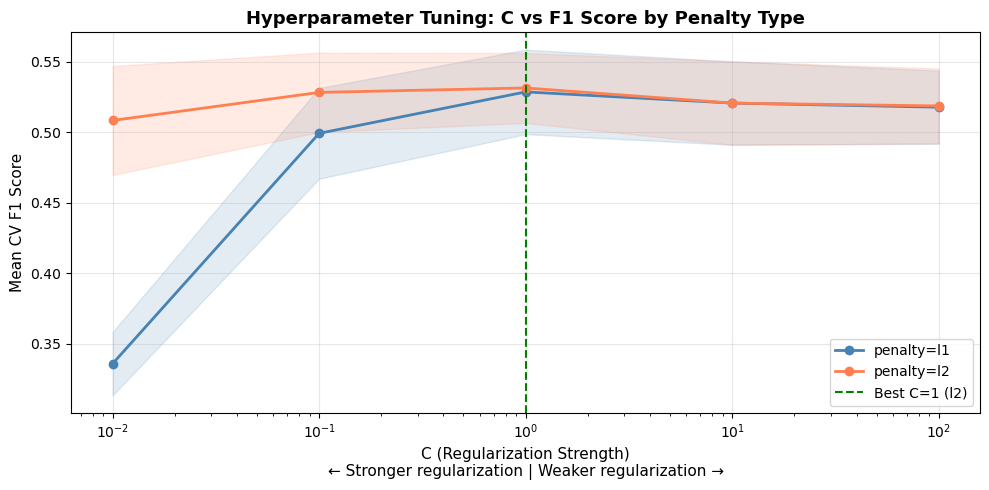

Plot saved. Best combination: C=1, penalty=l2, F1=0.5315


In [71]:
# ── Visualize tuning results ──────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

# Plot a line for each penalty type showing how F1 changes with C
colors = {'l1': 'steelblue', 'l2': 'coral'}
for penalty in ['l1', 'l2']:
    mask   = results_df['param_penalty'] == penalty
    subset = results_df[mask].sort_values('param_C')
    c_vals = subset['param_C'].astype(float)
    f1_vals = subset['mean_test_score']
    std_vals = subset['std_test_score']

    ax.plot(c_vals, f1_vals, marker='o', linewidth=2,
            color=colors[penalty], label=f'penalty={penalty}')
    # Shaded band shows ± 1 standard deviation across folds
    ax.fill_between(c_vals, f1_vals - std_vals, f1_vals + std_vals,
                    alpha=0.15, color=colors[penalty])

# Mark the best combination
best_c       = grid_search.best_params_['C']
best_penalty = grid_search.best_params_['penalty']
best_f1      = grid_search.best_score_
ax.axvline(x=best_c, color='green', linestyle='--', linewidth=1.5,
           label=f'Best C={best_c} ({best_penalty})')

ax.set_xscale('log')  # log scale because C spans 0.01 → 100
ax.set_xlabel('C (Regularization Strength)\n← Stronger regularization | Weaker regularization →', fontsize=11)
ax.set_ylabel('Mean CV F1 Score', fontsize=11)
ax.set_title('Hyperparameter Tuning: C vs F1 Score by Penalty Type', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/lr_hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved. Best combination: C={best_c}, penalty={best_penalty}, F1={best_f1:.4f}")

In [72]:
# ── Retrieve and confirm the best model ──────────────────────────────────────
# grid_search.best_estimator_ is already the best model, retrained on full training data
# We do NOT need to manually create a new model — GridSearchCV handles this

best_lr = grid_search.best_estimator_

print("Final tuned model parameters:")
print(f"  C (regularization):   {best_lr.C}")
print(f"  Penalty:              {best_lr.penalty}")
print(f"  Class weight:         {best_lr.class_weight}")
print(f"  Solver:               {best_lr.solver}")
print(f"  Max iterations:       {best_lr.max_iter}")
print(f"  Converged in:         {best_lr.n_iter_[0]} iterations")

# Update predictions using the tuned model
y_pred       = best_lr.predict(X_test)
y_pred_proba = best_lr.predict_proba(X_test)[:, 1]

print(f"\nPredictions updated using tuned model.")

Final tuned model parameters:
  C (regularization):   1
  Penalty:              l2
  Class weight:         balanced
  Solver:               liblinear
  Max iterations:       1000
  Converged in:         6 iterations

Predictions updated using tuned model.


In [73]:
# ── Compare default model vs tuned model ─────────────────────────────────────
# Let's see how much tuning actually improved things

# Default model predictions (from Section 2)
y_pred_default = lr_model.predict(X_test)
y_pred_default_proba = lr_model.predict_proba(X_test)[:, 1]

# Compare key metrics
print("Default Model vs Tuned Model Comparison:")
print("-" * 55)
print(f"{'Metric':<15} {'Default':>15} {'Tuned':>15}")
print("-" * 55)

metrics = {
    'Accuracy':  (accuracy_score, {}),
    'Precision': (precision_score, {}),
    'Recall':    (recall_score, {}),
    'F1 Score':  (f1_score, {}),
    'ROC-AUC':   (roc_auc_score, {'y_score': True})
}

for metric_name, (metric_fn, kwargs) in metrics.items():
    if 'y_score' in kwargs:
        default_val = metric_fn(y_test, y_pred_default_proba)
        tuned_val   = metric_fn(y_test, y_pred_proba)
    else:
        default_val = metric_fn(y_test, y_pred_default)
        tuned_val   = metric_fn(y_test, y_pred)
    improvement = tuned_val - default_val
    arrow = '↑' if improvement > 0 else ('↓' if improvement < 0 else '=')
    print(f"{metric_name:<15} {default_val:>15.4f} {tuned_val:>13.4f} {arrow}")

print("-" * 55)

Default Model vs Tuned Model Comparison:
-------------------------------------------------------
Metric                  Default           Tuned
-------------------------------------------------------
Accuracy                 0.7721        0.7721 =
Precision                0.3864        0.3864 =
Recall                   0.7234        0.7234 =
F1 Score                 0.5037        0.5037 =
ROC-AUC                  0.8105        0.8106 ↑
-------------------------------------------------------


Summary

| What we tuned | Why | Method |
|---|---|---|
| `C` (regularization strength) | Controls overfitting vs underfitting tradeoff | Tried 5 values: 0.01 → 100 |
| `penalty` (L1 vs L2) | L1 can zero out irrelevant features; L2 smoothly shrinks all | Tried both |
| Cross-validation | Reliable evaluation that doesn't depend on one lucky split | 5-fold stratified |
| Scoring metric | F1 instead of accuracy — correct for imbalanced data | `scoring='f1'` |

### 2. SVM

### 3. XGBoost/Random Forest
---

## **Evaluation Metrics & Visualizations**


### 1.  Logistic Regression
All metrics use the **tuned model** (`best_lr`) on the **test set** (294 employees never seen during training).

In [74]:
# ── COMPREHENSIVE METRICS SUMMARY ───────────────────────────────────────────
# Compute all required metrics using the tuned model predictions
# y_pred       = binary predictions (0 or 1)
# y_pred_proba = probability of leaving (0.0 to 1.0)
# y_test       = actual real answers

acc     = accuracy_score(y_test, y_pred)
prec    = precision_score(y_test, y_pred)
rec     = recall_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print('=' * 52)
print('   LOGISTIC REGRESSION — EVALUATION SUMMARY')
print('=' * 52)
print(f'  Accuracy :  {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision:  {prec:.4f}')
print(f'  Recall   :  {rec:.4f}')
print(f'  F1-Score :  {f1:.4f}')
print(f'  ROC-AUC  :  {roc_auc:.4f}')
print('=' * 52)

# Full per-class breakdown — shows metrics separately for class 0 (Stayed) and class 1 (Left)
print('\nFull Classification Report:')
print(classification_report(y_test, y_pred, target_names=['0 - Stayed', '1 - Left']))

# Metric interpretations specific to our attrition problem
print('Metric Interpretation:')
print(f'  Accuracy {acc*100:.1f}% : not reliable alone — predicting everyone stays gives 83.9% trivially')
print(f'  Precision {prec:.2f}   : of all employees predicted to leave, {prec*100:.1f}% actually did')
print(f'  Recall {rec:.2f}      : of all who actually left, we correctly caught {rec*100:.1f}%')
print(f'  F1 {f1:.2f}          : balance between precision and recall')
print(f'  ROC-AUC {roc_auc:.2f}    : model correctly ranks a leaver above a stayer {roc_auc*100:.1f}% of the time')

   LOGISTIC REGRESSION — EVALUATION SUMMARY
  Accuracy :  0.7721  (77.21%)
  Precision:  0.3864
  Recall   :  0.7234
  F1-Score :  0.5037
  ROC-AUC  :  0.8106

Full Classification Report:
              precision    recall  f1-score   support

  0 - Stayed       0.94      0.78      0.85       247
    1 - Left       0.39      0.72      0.50        47

    accuracy                           0.77       294
   macro avg       0.66      0.75      0.68       294
weighted avg       0.85      0.77      0.80       294

Metric Interpretation:
  Accuracy 77.2% : not reliable alone — predicting everyone stays gives 83.9% trivially
  Precision 0.39   : of all employees predicted to leave, 38.6% actually did
  Recall 0.72      : of all who actually left, we correctly caught 72.3%
  F1 0.50          : balance between precision and recall
  ROC-AUC 0.81    : model correctly ranks a leaver above a stayer 81.1% of the time


In [75]:
# ── SAVE TRAINED MODEL ────────────────────────────────────────────────────────
# joblib saves the entire trained model object to a file
# This lets you reload it later without retraining
import joblib

joblib.dump(best_lr, 'Supervised_Learning/models/logistic_regression_model.pkl')
print("Model saved to Supervised_Learning/models/logistic_regression_model.pkl")

# To reload it later in any notebook:
# loaded_model = joblib.load('Supervised_Learning/models/logistic_regression_model.pkl')

Model saved to Supervised_Learning/models/logistic_regression_model.pkl


In [ ]:
# ── SAVE EVALUATION RESULTS ───────────────────────────────────────────────────
# Save all metrics to a CSV so results are readable without rerunning the notebook
metrics_dict = {
    'Model':     ['Logistic Regression'],
    'Accuracy':  [round(acc, 4)],
    'Precision': [round(prec, 4)],
    'Recall':    [round(rec, 4)],
    'F1':        [round(f1, 4)],
    'ROC_AUC':   [round(roc_auc, 4)]
}

metrics_df = pd.DataFrame(metrics_dict)
metrics_df.to_csv('Supervised_Learning/evaluation_results/lr_metrics.csv', index=False)
print("Metrics saved to Supervised_Learning/evaluation_results/lr_metrics.csv")
print(metrics_df.to_string(index=False))

OSError: Cannot save file into a non-existent directory: '..\Supervised_Learning\evaluation_results'

#### Confusion Matrix Heatmap

The confusion matrix breaks down all 294 test predictions into 4 categories:

| | Predicted: Stayed | Predicted: Left |
|---|---|---|
| **Actual: Stayed** | True Negative (TN) | False Positive (FP) |
| **Actual: Left** | False Negative (FN) ← most critical | True Positive (TP) |

**False Negatives** are the most costly — employees who were about to leave but the model missed them, so no HR intervention happened.

In [ ]:
# ── CONFUSION MATRIX HEATMAP ─────────────────────────────────────────────────

# confusion_matrix() returns a 2x2 array: [[TN, FP], [FN, TP]]
cm = confusion_matrix(y_test, y_pred)

# .ravel() flattens [[TN,FP],[FN,TP]] into [TN, FP, FN, TP] for easy unpacking
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(7, 5))

# ConfusionMatrixDisplay draws a color-coded grid with counts in each cell
# Blues colormap: darker = higher count
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Stayed (0)', 'Left (1)']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Logistic Regression - Confusion Matrix\n(Test Set: 294 employees)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
import os
os.makedirs('Supervised_Learning/plots', exist_ok=True)
plt.savefig('Supervised_Learning/plots/lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print interpretation of each cell
print(f'True Negatives  (predicted Stayed,  actually Stayed): {tn}')
print(f'False Positives (predicted Left,     actually Stayed): {fp}  <- false alarm')
print(f'False Negatives (predicted Stayed,  actually Left):   {fn}  <- MISSED attritions (most critical)')
print(f'True Positives  (predicted Left,     actually Left):   {tp}  <- correctly caught')
print(f'\nOut of {fn+tp} employees who actually left:')
print(f'  Model caught {tp} ({tp/(fn+tp)*100:.1f}%) correctly')
print(f'  Model missed {fn} ({fn/(fn+tp)*100:.1f}%) - these are the most costly errors for HR')

#### ROC Curve

The ROC curve shows the tradeoff between:
- **True Positive Rate (Recall):** how many actual leavers we correctly catch
- **False Positive Rate:** how many stayers we incorrectly flag as leavers

A perfect model hugs the top-left corner. The diagonal dashed line = random guessing.  
**AUC closer to 1.0 = better model.**

In [ ]:
# ── ROC CURVE ────────────────────────────────────────────────────────────────

# roc_curve() needs probability scores (y_pred_proba), NOT binary labels (y_pred)
# It computes TPR and FPR at every possible classification threshold
# This lets us see the full tradeoff, not just the 0.5 threshold result
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))

# The ROC curve itself
ax.plot(fpr, tpr, color='steelblue', linewidth=2.5,
        label=f'Logistic Regression (AUC = {roc_auc:.4f})')

# Light shading under the curve to highlight the area
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')

# Diagonal dashed line = random classifier (AUC = 0.50)
# Any model curve above this line is better than random guessing
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')

ax.set_xlabel('False Positive Rate\n(Stayers incorrectly flagged as Leavers)', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)\n(Leavers correctly identified)', fontsize=11)
ax.set_title('ROC Curve - Logistic Regression', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/lr_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'AUC = {roc_auc:.4f}')
print(f'Interpretation: model correctly ranks a leaver above a stayer {roc_auc*100:.1f}% of the time')
print(f'Benchmark: 0.50 = random guessing | 1.00 = perfect model')

#### Feature Coefficients Plot

Logistic Regression assigns a **coefficient** to every feature after training:

- **Red bar (positive)** → feature increases probability of leaving
- **Blue bar (negative)** → feature decreases probability of leaving
- **Longer bar** → stronger influence on the prediction

This is the Logistic Regression equivalent of feature importance plots used in tree-based models like XGBoost.

In [ ]:
# ── FEATURE COEFFICIENTS BAR CHART ──────────────────────────────────────────

# best_lr.coef_[0] is a 1D array of 53 values, one coefficient per feature
# Positive coefficient = this feature pushes prediction toward 'Left'
# Negative coefficient = this feature pushes prediction toward 'Stayed'
coef_plot_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': best_lr.coef_[0]
})

# Sort by absolute value so the most influential features appear at the top
# regardless of whether they are positive or negative
coef_plot_df = coef_plot_df.reindex(
    coef_plot_df['Coefficient'].abs().sort_values(ascending=False).index
).head(20)  # top 20 most influential features only

# Red for positive (attrition risk increasers), blue for negative (retention factors)
colors = ['#d73027' if c > 0 else '#4575b4' for c in coef_plot_df['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(coef_plot_df['Feature'], coef_plot_df['Coefficient'], color=colors)

# Vertical line at 0 to clearly separate positive from negative
ax.axvline(x=0, color='black', linewidth=0.8)

ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title(
    'Top 20 Feature Coefficients - Logistic Regression\n'
    'Red = increases attrition risk  |  Blue = decreases attrition risk',
    fontsize=13, fontweight='bold'
)
ax.invert_yaxis()  # most influential feature at top
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('Supervised_Learning/plots/lr_feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features INCREASING attrition risk:')
top_pos = coef_plot_df[coef_plot_df['Coefficient'] > 0].head(5)
print(top_pos[['Feature', 'Coefficient']].to_string(index=False))
print('\nTop 5 features DECREASING attrition risk:')
top_neg = coef_plot_df[coef_plot_df['Coefficient'] < 0].tail(5)
print(top_neg[['Feature', 'Coefficient']].to_string(index=False))

### 2. SVM

### 3. XGBoost/Random Forest
---

## **Model Comparison & Analysis**

## **Conclusion: Best Model Selection & Reasoning**